In [36]:
import os,sys
print(os.getcwd())
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print("Project root directory:", project_root)
sys.path.append(project_root)

/home/zhaolei/meal-rec-ai/preprocess
Project root directory: /home/zhaolei/meal-rec-ai


In [37]:
from utils.data import concat_data_across_years,root_path
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

### Food Code

In [24]:
"""
This is merely for information. Not used in the pipeline.

We use the food code NHANES provided, which is more complete than FNDDS. For duplications, we also keep the latest records.
In this way, every food users reported has its corresponding food description.
We use this as the connections between users and food.
"""
def Food_Code():
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_dietary = 'dietary'
    df_CD = concat_data_across_years(type_dietary, 'DRXFCD', years, year_char)
    df_CD = df_CD.rename(columns={'DRXFDCD': 'food_id'})
    df_CD = df_CD.rename(columns={'DRXFCSD': 'food_desc'})
    df_CD = df_CD.rename(columns={'DRXFCLD': 'food_desc_long'})
    df_CD['food_id'] = df_CD['food_id'].astype(int).astype(str)
    #df_CD['food_id'] = df_CD['food_id'].str.zfill(10)
    df_CD=df_CD.drop(columns=['DRXFFCSD','DRXFFDLD'])
    # 将 df_CD 的 food_id 设置为索引
    df_CD = df_CD.drop_duplicates(subset=['food_id'], keep='first')
    df_CD.set_index('food_id', inplace=True)
    return df_CD

In [25]:
df_CD=Food_Code()

Food Positive / Negative Score based on category
| Category Number | Primary Category                                | Secondary Category Description                                 |
| --------------- | ----------------------------------------------- | -------------------------------------------------------------- |
| 1               | Milk and Milk Products                          | 11 Milks, milk drinks, yogurts, infant formulas                |
|                 |                                                 | 12 Creams and cream substitutes                                |
|                 |                                                 | 13 Milk desserts and sauces                                    |
|                 |                                                 | 14 Cheeses                                                     |
| 2               | Meat, Poultry, Fish, and Mixtures               | 20 Meat                                                        |
|                 |                                                 | 21 Beef                                                        |
|                 |                                                 | 22 Pork                                                        |
|                 |                                                 | 23 Lamb, veal, game                                            |
|                 |                                                 | 24 Poultry                                                     |
|                 |                                                 | 25 Organ meats, frankfurters, sausages, lunchmeats             |
|                 |                                                 | 26 Fish, shellfish                                             |
|                 |                                                 | 27 Meat, poultry, fish mixtures                                |
|                 |                                                 | 28 Frozen meals, soups, gravies                                |
| 3               | Eggs                                            | 31 Eggs                                                        |
|                 |                                                 | 32 Egg mixtures                                                |
|                 |                                                 | 33 Egg substitutes                                             |
| 4               | Dry Beans, Peas, Other Legumes, Nuts, and Seeds | 41 Legumes                                                     |
|                 |                                                 | 42 Nuts, nut butters, nut mixtures                             |
|                 |                                                 | 43 Seeds and seed mixtures                                     |
|                 |                                                 | 44 Carob products                                              |
| 5               | Grain Products                                  | 50 Flour and dry mixes                                         |
|                 |                                                 | 51 Yeast breads, rolls                                         |
|                 |                                                 | 52 Quick breads                                                |
|                 |                                                 | 53 Cakes, cookies, pies, pastries, bars                        |
|                 |                                                 | 54 Crackers, snack products                                    |
|                 |                                                 | 55 Pancakes, waffles, French toast, other grain products       |
|                 |                                                 | 56 Pastas, rice, cooked cereals                                |
|                 |                                                 | 57 Cereals, not cooked                                         |
|                 |                                                 | 58 Grain mixtures, frozen meals, soups                         |
|                 |                                                 | 59 Meat substitutes                                            |
| 6               | Fruits                                          | 61 Citrus fruits, juices                                       |
|                 |                                                 | 62 Dried fruits                                                |
|                 |                                                 | 63 Other fruits                                                |
|                 |                                                 | 64 Fruit juices and nectars excluding citrus                   |
|                 |                                                 | 67 Fruits and juices baby food                                 |
| 7               | Vegetables                                      | 71 White potatoes, starchy vegetables                          |
|                 |                                                 | 72 Dark-green vegetables                                       |
|                 |                                                 | 73 Orange vegetables                                           |
|                 |                                                 | 74 Tomatoes, tomato mixtures                                   |
|                 |                                                 | 75 Other vegetables                                            |
|                 |                                                 | 76 Vegetables and mixtures mostly vegetables baby food         |
|                 |                                                 | 77 Vegetables with meat, poultry, fish                         |
|                 |                                                 | 78 Mixtures mostly vegetables without meat, poultry, fish      |
| 8               | Fats, Oils, and Salad Dressings                 | 81 Fats                                                        |
|                 |                                                 | 82 Oils                                                        |
|                 |                                                 | 83 Salad dressings                                             |
|                 |                                                 | 89 ‘For use’ with a sandwich or vegetable                      |
| 9               | Sugars, Sweets, and Beverages                   | 91 Sugars, sweets                                              |
|                 |                                                 | 92 Nonalcoholic beverages                                      |
|                 |                                                 | 93 Alcoholic beverages                                         |
|                 |                                                 | 94 Noncarbonated water                                         |
|                 |                                                 | 95 Formulated nutrition beverages, energy drinks, sports drink |
|                 |                                                 | 99 Used as an ingredient, not for coding                       |


## Healthy score calculate rules

Postive Food
| Food Category Code | Category | Score |
| ---  | --- | --- |
| 7    | Vegetables | +1  |
| 6    | Fruits | +1 |
| 5    | Grain  | +1 |
| 26 | Fish | +1 |
| 24 | poultry | +1 |
| 4 | beans | +1 |

Negative Food
| Food Category Code | Category | Score |
| ---  | --- | --- |
| 20,21,22,23,25,27,28 | meet | +1 |
| 12,13,14 | milk | +1 |
| 9 | sugars | +1 |
| 81 | fats | +1 |

In [26]:
df_CD.head()

,food_desc,food_desc_long,years
food_id,,,
11000000,"MILK, HUMAN","Milk, human",0304
11100000,"MILK, NFS","Milk, NFS",0304
11111000,"MILK, COW'S, FLUID, WHOLE","Milk, cow's, fluid, whole",0304
11111100,"MILK, COW'S, FLUID, WHOLE, LOW SODIUM","Milk, cow's, fluid, whole, low-sodium",0304
11111150,"MILK, CALCIUM FORTIFIED, WHOLE, COW'S, FLUID","Milk, calcium fortified, cow's, fluid, whole",0304


In [27]:
from utils.health_evaluate import is_positive,is_negative
# 应用函数并保存结果
df_CD['positive'] = df_CD.index.map(is_positive)
df_CD['negative'] = df_CD.index.map(is_negative)
df_CD.to_csv(f'{root_path}food_code.csv')
df_CD

,food_desc,food_desc_long,years,positive,negative
food_id,,,,,
11000000,"MILK, HUMAN","Milk, human",0304,0,0
11100000,"MILK, NFS","Milk, NFS",0304,0,0
11111000,"MILK, COW'S, FLUID, WHOLE","Milk, cow's, fluid, whole",0304,0,0
11111100,"MILK, COW'S, FLUID, WHOLE, LOW SODIUM","Milk, cow's, fluid, whole, low-sodium",0304,0,0
11111150,"MILK, CALCIUM FORTIFIED, WHOLE, COW'S, FLUID","Milk, calcium fortified, cow's, fluid, whole",0304,0,0
...,...,...,...,...,...
94200100,"WATER, ENHANCED, REGULAR","Water, enhanced, regular",1720,0,1
94200200,"WATER, ENHANCED, DIET","Water, enhanced, diet",1720,0,1
99991410,CHEESE AND QUESO AS INGREDIENT,Cheese and Queso as ingredient,1720,0,1


### Dietary Record Data

In [28]:
def Dietary():
    years = ['0304', '0506', '0708', '0910', '1112', '1314', '1516', '1718', '1720']
    year_char = 'C'
    type_dietary = 'dietary'
    df_IFF1 = concat_data_across_years(type_dietary, 'DR1IFF', years, year_char)
    df_IFF2 = concat_data_across_years(type_dietary, 'DR2IFF', years, year_char)

    # Food and nutrition data
    food_columns_1 = ['SEQN', 'food_id', 'eating_type', 'grams', 'day',
                      'DR1IKCAL', 'DR1IPROT', 'DR1ICARB', 'DR1ISUGR', 'DR1IFIBE',
                      'DR1ISFAT', 'DR1ICHOL', 'DR1IFA', 'DR1IVB12',
                      'DR1IVC', 'DR1IVD', 'DR1ICALC', 'DR1IPHOS','DR1IPOTA', 'DR1IIRON', 'DR1ISODI',
                      ]
    food_columns_2 = ['SEQN', 'food_id', 'eating_type', 'grams', 'day',
                      'DR2IKCAL', 'DR2IPROT', 'DR2ICARB', 'DR2ISUGR', 'DR2IFIBE',
                      'DR2ISFAT', 'DR2ICHOL', 'DR2IFA', 'DR2IVB12',
                      'DR2IVC', 'DR2IVD', 'DR2ICALC', 'DR2IPHOS', 'DR2IPOTA','DR2IIRON', 'DR2ISODI'
                      ]
    df_IFF1 = df_IFF1.rename(columns={'DR1IFDCD': 'food_id'})
    df_IFF1 = df_IFF1.rename(columns={'DR1_030Z': 'eating_type'})
    df_IFF1 = df_IFF1.rename(columns={'DR1IGRMS': 'grams'})
    df_IFF1 = df_IFF1.rename(columns={'DR1DAY': 'day'})
    df_IFF1['day'] = 1
    df_IFF1 = df_IFF1[food_columns_1].astype(float)
    df_IFF2 = df_IFF2.rename(columns={'DR2IFDCD': 'food_id'})
    df_IFF2 = df_IFF2.rename(columns={'DR2_030Z': 'eating_type'})
    df_IFF2 = df_IFF2.rename(columns={'DR2IGRMS': 'grams'})
    df_IFF2 = df_IFF2.rename(columns={'DR2DAY': 'day'})
    df_IFF2['day'] = 2
    df_IFF2 = df_IFF2[food_columns_2].astype(float)
    df_food = pd.DataFrame(np.vstack((df_IFF1.to_numpy(), df_IFF2.to_numpy())), columns=df_IFF1.columns)
    nutrition_mapping = {'DR1IKCAL': 'calorie', 'DR1IPROT': 'protein', 'DR1ICARB': 'carb', 'DR1ISUGR': 'sugar',
                         'DR1IFIBE': 'fiber',
                         'DR1ISFAT': 'saturated_fat', 'DR1ICHOL': 'cholesterol', 'DR1ISODI': 'sodium',
                         'DR1ICALC': 'calcium', 'DR1IPHOS': 'phosphorus',
                         'DR1IPOTA': 'potassium', 'DR1IIRON': 'iron', 'DR1IFA': 'folic_acid', 'DR1IVC': 'vitamin_c',
                         'DR1IVD': 'vitamin_d', 'DR1IVB12': 'vitamin_b12'
                         }
    df_food = df_food.rename(columns=nutrition_mapping)
    df_food[['SEQN', 'food_id']] = df_food[['SEQN', 'food_id']].astype(int).astype(str)
    #df_food['food_id'] = df_food['food_id'].str.zfill(10)
    df_food_user = df_food[['SEQN', 'food_id', 'eating_type', 'grams', 'day']]
    df_food = df_food.drop(columns=['SEQN', 'eating_type','day'])
    df_food = df_food.drop_duplicates(subset=['food_id', 'grams'])
    return df_food, df_food_user

- Code or Value	Value Description	
- 1	Breakfast	
- 2	Lunch	
- 3	Dinner	
- 4	Supper	
- 5	Brunch	
- 6	Snack	
- 7	Drink	
- 8	Infant feeding	
- 9	Extended consumption	
- 10	Desayano (breakfast)	
- 11	Almuerzo (breakfast)	
- 12	Comida (lunch)	
- 13	Merienda (snack)	
- 14	Cena (dinner)	
- 15	Entre comida (snack)	
- 16	Botana (snack)	
- 17	Bocadillo (snack)	
- 18	Tentempie (snack)	
- 19	Bebida (drink)	
- 91	Other	
- 99	Don't know	2	
- .	Missing


In [29]:
# This is the crosswalk between users and food records.
df_food,df_food_user=Dietary()

In [30]:
df_food.columns

Index(['food_id', 'grams', 'calorie', 'protein', 'carb', 'sugar', 'fiber',
       'saturated_fat', 'cholesterol', 'folic_acid', 'vitamin_b12',
       'vitamin_c', 'vitamin_d', 'calcium', 'phosphorus', 'potassium', 'iron',
       'sodium'],
      dtype='object')

In [31]:
df_food.to_csv(f'{root_path}food_nutrition.csv',index=False)

In [32]:
# 将 df_CD 的 food_desc 列合并到 df_food_user 中
df_food_user.set_index('food_id', inplace=True)
df_food_user = df_food_user.join(df_CD)
df_food_user=df_food_user.drop(columns=['food_desc','food_desc_long','positive','negative'])
df_food_user = df_food_user.rename(columns={'SEQN': 'user_id'})
df_food_user['daily_food_id'] = df_food_user['user_id'].astype(str)  + \
                                df_food_user['years'].astype(str) + \
                                df_food_user['day'].astype(int).astype(str)
# 重置索引
df_food_user.reset_index(inplace=True)

In [33]:
df_food_user

,food_id,user_id,eating_type,grams,day,years,daily_food_id
0,91745020,21005,9.0,6.00,1.0,0304,2100503041
1,92410710,21005,6.0,616.00,1.0,0304,2100503041
2,71201010,21005,6.0,50.00,1.0,0304,2100503041
3,25230230,21005,2.0,112.00,1.0,0304,2100503041
4,51301010,21005,2.0,104.00,1.0,0304,2100503041
...,...,...,...,...,...,...,...
2322622,27214100,124820,4.0,114.00,2.0,0304,12482003042
2322623,25210210,124820,2.0,57.00,2.0,0304,12482003042
2322624,71200100,124820,2.0,37.50,2.0,1516,12482015162
2322625,64104030,124820,2.0,124.00,2.0,1314,12482013142


In [34]:
df_food_user.to_csv(f'{root_path}food_user.csv', index=False)

# Visualization

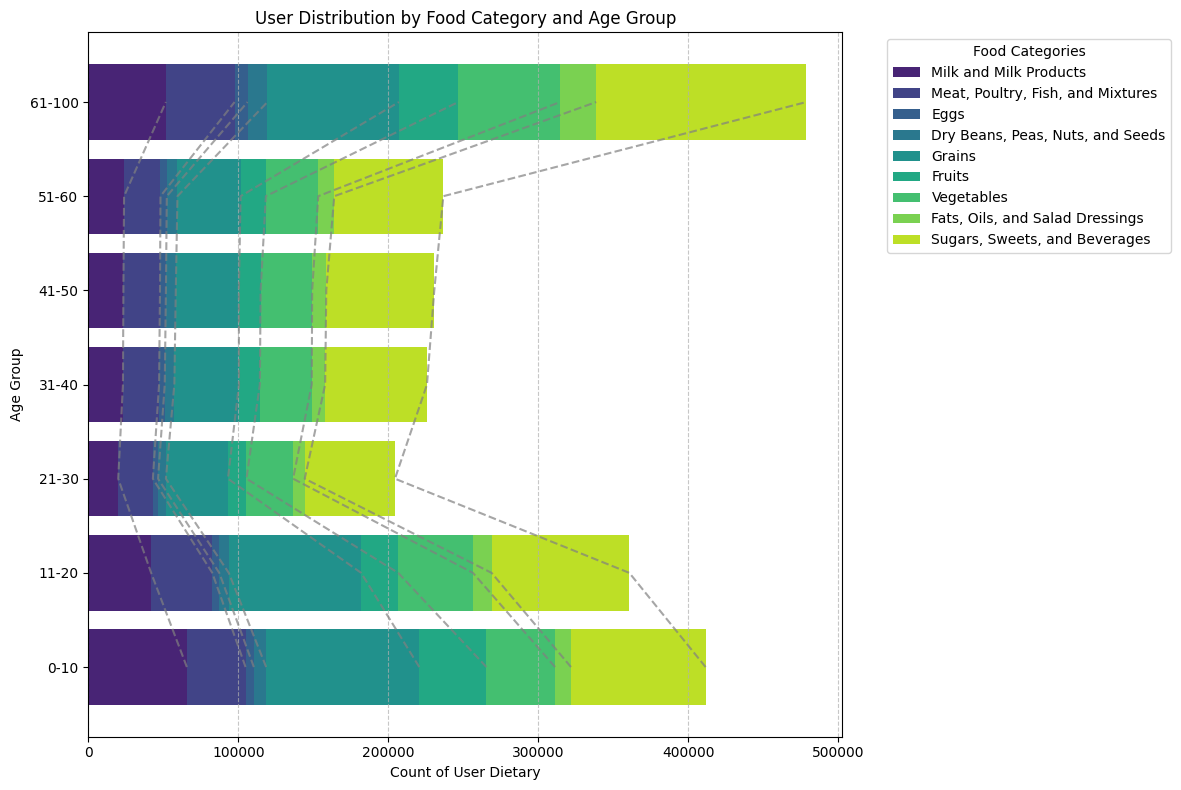

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read data files
df_food_user = pd.read_csv(f'{root_path}food_user.csv')
df_user = pd.read_csv(f'{root_path}users.csv')
df_food_user = df_food_user.merge(df_user[['user_id', 'age_group']], on='user_id', how='left')

# Data preprocessing
food_category_map = {
    '1': 'Milk and Milk Products',
    '2': 'Meat, Poultry, Fish, and Mixtures',
    '3': 'Eggs',
    '4': 'Dry Beans, Peas, Nuts, and Seeds',
    '5': 'Grains',
    '6': 'Fruits',
    '7': 'Vegetables',
    '8': 'Fats, Oils, and Salad Dressings',
    '9': 'Sugars, Sweets, and Beverages'
}
age_group_mapping = {
    1: '0-10',
    2: '11-20',
    3: '21-30',
    4: '31-40',
    5: '41-50',
    6: '51-60',
    7: '61-100'
}

# Extract the first digit of food_id as food category
df_food_user['food_category'] = df_food_user['food_id'].astype(str).str[:1]
df_food_user['food_category'] = df_food_user['food_category'].map(food_category_map)
df_food_user['age_group'] = df_food_user['age_group'].map(age_group_mapping)

# Calculate user food statistics
user_food_stats = df_food_user.groupby(['user_id', 'age_group', 'day', 'food_category']).size().reset_index(name='count')

# Calculate food category statistics by age group
age_group_food_stats = user_food_stats.groupby(['age_group', 'food_category'])['count'].sum().unstack(fill_value=0)

# Define fixed order for age groups and food categories
age_groups_order = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-100']
food_categories_order = [
    'Milk and Milk Products',
    'Meat, Poultry, Fish, and Mixtures',
    'Eggs',
    'Dry Beans, Peas, Nuts, and Seeds',
    'Grains',
    'Fruits',
    'Vegetables',
    'Fats, Oils, and Salad Dressings',
    'Sugars, Sweets, and Beverages'
]

# Create a color palette for food categories using viridis with increased contrast
num_categories = len(food_categories_order)
viridis = sns.color_palette("viridis", n_colors=num_categories )  # Generate more colors
food_colors = [viridis[i] for i in range(num_categories)]  # Select every third color
food_color_map = {food: color for food, color in zip(food_categories_order, food_colors)}

# Prepare the figure
plt.figure(figsize=(12, 8))

# Store the right edges of each food category for connector lines
right_edges = {food: [] for food in food_categories_order}

# Plot each age group's food counts
for i, age_group in enumerate(age_groups_order):
    counts = age_group_food_stats.loc[age_group]
    cumulative_count = 0
    
    for food_category in food_categories_order:
        count = counts[food_category]
        if count > 0:
            # Draw the bar segment without edgecolor
            plt.barh(
                i,
                count,
                left=cumulative_count,
                color=food_color_map[food_category],
                label=food_category if i == 0 else ""
            )
            
            # Record the right edge of the current food category segment
            right_edge = cumulative_count + count
            right_edges[food_category].append((right_edge, i))
            
            cumulative_count += count

# Draw connector lines at the right edges of each food category
for food_category in food_categories_order:
    edges = right_edges[food_category]
    if len(edges) >= 2:
        # Extract x and y coordinates for the connector line
        x_coords = [edge[0] for edge in edges]
        y_coords = [edge[1] for edge in edges]
        
        # Draw the connector line
        plt.plot(
            x_coords,
            y_coords,
            linestyle='--',
            color='gray',
            alpha=0.7
        )

# Customize the plot
plt.yticks(range(len(age_groups_order)), age_groups_order)
plt.xlabel('Count of User Dietary')
plt.ylabel('Age Group')
plt.title('User Distribution by Food Category and Age Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(
    title='Food Categories',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()

# Display the plot
plt.show()